In [1]:
import sys
from pathlib import Path

current = Path().resolve()

for parent in [current] + list(current.parents):
    if (parent / "backend").exists():
        sys.path.append(str(parent))
        print("Project root found:", parent)
        break

Project root found: D:\Projects\Thesis\sem10\pipeline


In [2]:
import pandas as pd
from backend.config import settings

DATASET_PATH = settings.RECON_OUTPUT_FOLDER / "training_dataset.csv"

df = pd.read_csv(DATASET_PATH)

# convert labels
df["label"] = df["label"].map({"n": 0, "d": 1})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13812, 12)


,area_um2,perimeter,circularity,elongation,mean_phase,std_phase,min_phase,max_phase,MCH_surface_density,optical_volume,label,sample
0,60.83,318.066017,0.755602,1.486496,0.399327,0.320484,-1.007774,1.244906,2.235011,24.291042,1,a10_1_d__r6_1_d
1,65.19,376.722871,0.577227,2.791146,0.302766,0.277780,-0.569725,0.691885,1.694568,19.737339,1,a10_1_d__r6_1_d
2,225.22,565.688384,0.884428,1.145016,0.529078,0.286889,-0.516483,1.152088,2.961224,119.159002,1,a10_1_d__r6_1_d
3,227.42,575.813275,0.861936,1.077949,1.134185,0.380293,-0.244228,1.960601,6.347976,257.936370,1,a10_1_d__r6_1_d
4,268.39,653.381818,0.790027,1.335597,0.659878,0.329374,-0.556560,1.317423,3.693300,177.104517,1,a10_1_d__r6_1_d


In [3]:
"mean_phase" in df.columns
df["mean_phase"].head()

0    0.399327
1    0.302766
2    0.529078
3    1.134185
4    0.659878
Name: mean_phase, dtype: float64

In [4]:
import numpy as np

df["mean_phase"] = pd.to_numeric(df["mean_phase"], errors="coerce")
df = df.dropna(subset=["mean_phase"])

print("Dataset size after cleaning:", df.shape)

Dataset size after cleaning: (13812, 12)


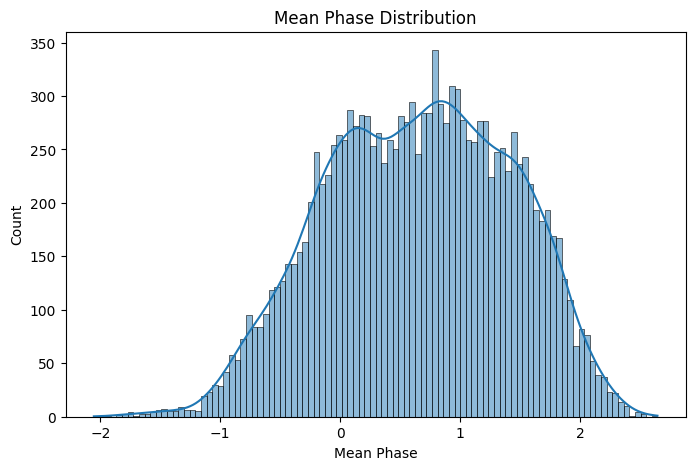

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["mean_phase"], bins=100, kde=True)

plt.title("Mean Phase Distribution")
plt.xlabel("Mean Phase")
plt.ylabel("Count")

plt.show()

<Axes: xlabel='mean_phase', ylabel='Count'>

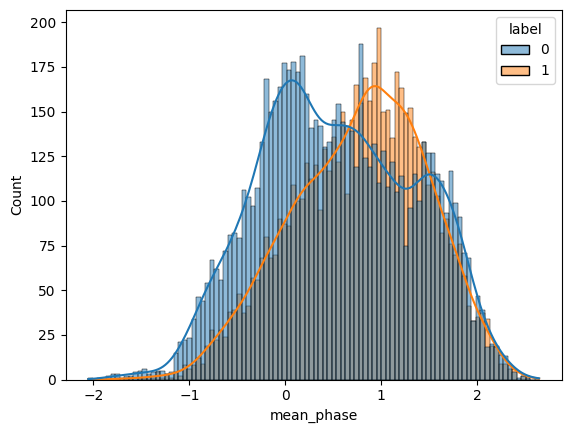

In [6]:
import seaborn as sns

sns.histplot(data=df, x="mean_phase", hue="label", bins=100, kde=True)

In [7]:
print(df["mean_phase"].min(), df["mean_phase"].max())

-2.0542111 2.6462543


In [6]:
image_stats = df.groupby("sample").agg({
    "std_phase": "mean",
    "mean_phase": "mean",
    "area_um2": "count"
}).rename(columns={"area_um2": "cell_count"})

image_stats.head()

,std_phase,mean_phase,cell_count
sample,,,
a10_1_d__r6_1_d,0.309043,0.574522,54
a10_1_n__r14_1_n,0.347844,1.757639,30
a10_2_d__r5_2_d,0.278730,0.046373,49
a10_2_n__r8_2_n,0.174917,-1.225266,16
a11_1_d__r1_1_d,0.324229,-0.060256,60


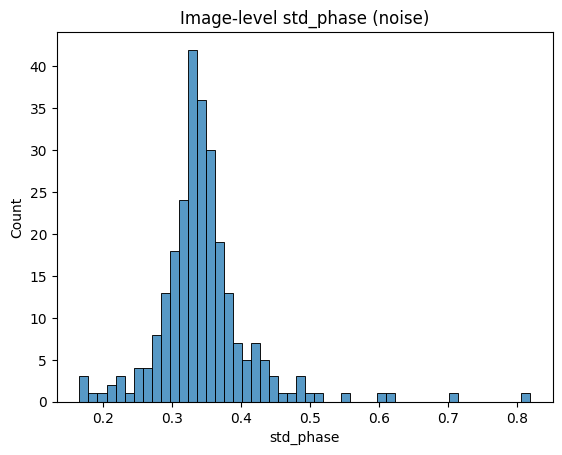

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(image_stats["std_phase"], bins=50)
plt.title("Image-level std_phase (noise)")
plt.show()

In [7]:
std_thresh = 0.45

good_images = image_stats[
    image_stats["std_phase"] <= std_thresh
].index

df_clean = df[df["sample"].isin(good_images)]

print("Original images:", len(image_stats))
print("Remaining images:", len(good_images))

print("Original rows:", len(df))
print("After filtering:", len(df_clean))

Original images: 261
Remaining images: 248
Original rows: 13812
After filtering: 13167


In [8]:
bad_images = image_stats[
    image_stats["std_phase"] > std_thresh
]

print("Bad images removed:", len(bad_images))
bad_images.sort_values("std_phase", ascending=False).head(10)

Bad images removed: 13


,std_phase,mean_phase,cell_count
sample,,,
a51_2_n__r3_2_n,0.818726,1.365035,1
a1_1_d__r6_1_d,0.714072,0.470022,9
a51_2_d__r11_2_d,0.610016,0.924043,79
a13_1_d__r7_1_d,0.609576,0.758262,31
a56_2_d__r5_2_d,0.548245,1.033485,54
a38_1_d__r2_1_d,0.515836,1.195353,81
a38_2_d__r12_2_d,0.493941,0.346879,46
a44_1_d__r4_1_d,0.492130,0.395514,84
a4_1_n__r14_1_n,0.490358,1.509135,36


<Axes: xlabel='mean_phase', ylabel='Count'>

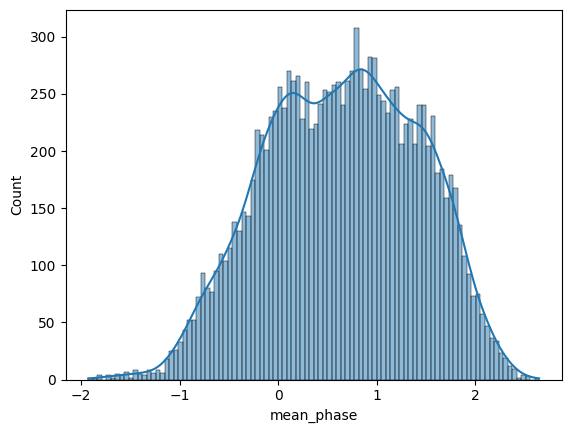

In [12]:
sns.histplot(df_clean["mean_phase"], bins=100, kde=True)

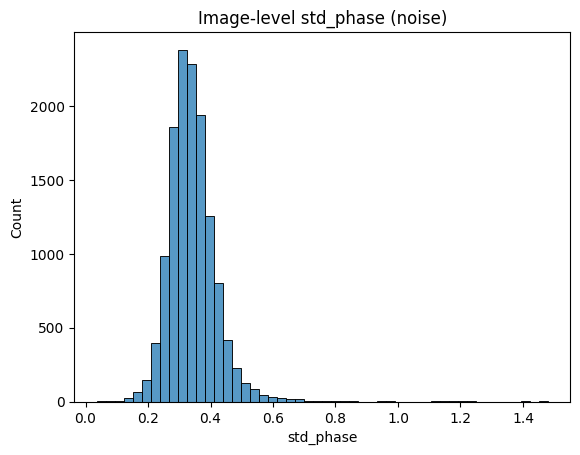

In [13]:
sns.histplot(df_clean["std_phase"], bins=50)
plt.title("Image-level std_phase (noise)")
plt.show()

In [9]:
df_clean = df_clean[df_clean["area_um2"] > 20]

In [10]:
features = [
    "area_um2",
    "perimeter",
    "circularity",
    "elongation",
    "mean_phase",
    "std_phase",
    "min_phase",
    "max_phase",
    "MCH_surface_density",
    "optical_volume"
]

In [11]:
from sklearn.model_selection import train_test_split

unique_images = df_clean["sample"].unique()

train_imgs, test_imgs = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=42
)

train_df = df_clean[df_clean["sample"].isin(train_imgs)]
test_df  = df_clean[df_clean["sample"].isin(test_imgs)]

In [12]:
X_train = train_df[features].values
y_train = train_df["label"].values

X_test = test_df[features].values
y_test = test_df["label"].values

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = train_df[features].values
X_test  = test_df[features].values

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import xgboost as xgb

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

clf = XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=50,   # increase if you want better results
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

In [17]:
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
}

In [18]:
results = {}

for name, model in models.items():
    print(f"\n🔹 {name}")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    
    results[name] = report


🔹 SVM
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      1543
           1       0.75      0.66      0.70      1114

    accuracy                           0.76      2657
   macro avg       0.76      0.75      0.75      2657
weighted avg       0.76      0.76      0.76      2657


🔹 Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1543
           1       0.68      0.65      0.66      1114

    accuracy                           0.72      2657
   macro avg       0.71      0.71      0.71      2657
weighted avg       0.72      0.72      0.72      2657


🔹 Random Forest
              precision    recall  f1-score   support

           0       0.76      0.83      0.79      1543
           1       0.73      0.65      0.68      1114

    accuracy                           0.75      2657
   macro avg       0.75      0.74      0.74      2657
weighted avg       0.75    

In [19]:
import pandas as pd

for name, model in models.items():
    print(f"\n🔸 Image-level: {name}")
    
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    temp_df = test_df.copy()
    temp_df["cell_prob"] = y_proba

    image_preds = temp_df.groupby("sample").agg({
        "cell_prob": "mean",
        "label": "first"
    }).reset_index()

    image_preds["image_pred"] = (image_preds["cell_prob"] > 0.4).astype(int)

    print(classification_report(
        image_preds["label"],
        image_preds["image_pred"]
    ))


🔸 Image-level: SVM
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        25
           1       0.80      0.80      0.80        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50


🔸 Image-level: Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        25
           1       0.79      0.88      0.83        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50


🔸 Image-level: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.81      0.88      0.85        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.8

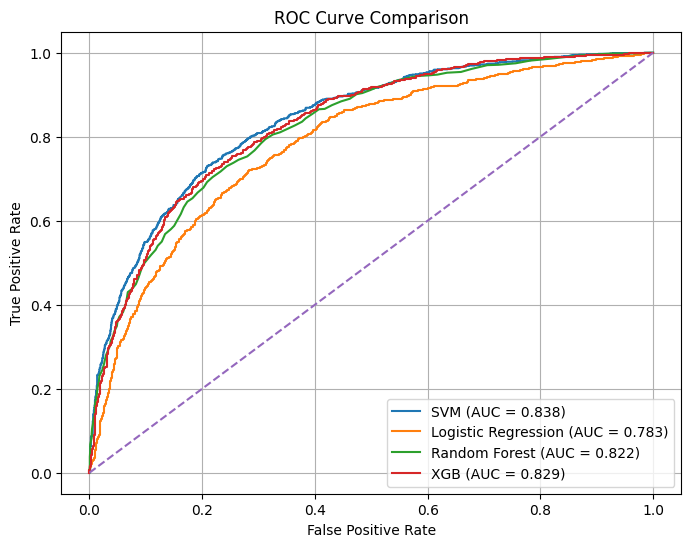

In [20]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():

    # Probability predictions
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # AUC
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

thresholds = np.linspace(0.2, 0.8, 7)  # fewer points for readability

for t in thresholds:
    print(f"\n🔹 Threshold = {t:.2f}")
    
    preds = (image_preds["cell_prob"] > t).astype(int)
    
    print(classification_report(
        image_preds["label"],
        preds
    ))

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

In [ ]:
y_proba = clf.predict_proba(X_test_scaled)[:, 1]
    
temp_df = test_df.copy()
temp_df["cell_prob"] = y_proba

image_preds = temp_df.groupby("sample").agg({
    "cell_prob": "mean",
    "label": "first"
}).reset_index()

image_preds["image_pred"] = (image_preds["cell_prob"] > 0.4).astype(int)

print(classification_report(
    image_preds["label"],
    image_preds["image_pred"]
))

In [ ]:
import joblib

joblib.dump(clf, "../models/xgboost_trained.pkl")
joblib.dump(features, "../models/features.pkl")
joblib.dump(0.4, "../models/threshold.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

metadata = {
    "model": "XGBoost",
    "threshold": 0.4,
    "features": features,
    "notes": "image-wise probability averaging"
}

joblib.dump(metadata, "../models/metadata.pkl")